# Notebook 02 — H3 Grid & Network Isochrones
## The 15-Minute Shanghai Project · Track C

Builds the spatial unit and computes **15-minute accessibility** for **six precise, legible criteria** (not vague
categories), by **walking** and **cycling**, using **real street-network distances** (Pozoukidou & Chatziyiannaki, 2021).

**Six accessibility criteria** (each = "reachable within 15 min walk or bike"):

| Critère | Définition concrète |
|---|---|
| 🛒 Courses alimentaires | supermarché, supérette ou marché alimentaire (*pas* les restaurants) |
| 🏥 Santé de proximité | hôpital, clinique, dispensaire ou pharmacie |
| 🏫 École | crèche, école, collège ou lycée |
| 🚉 Transport en commun | station de métro ou arrêt de bus |
| 🏦 Services essentiels | banque, poste, équipement public |
| 🌳 Parc / sport | parc, espace vert, terrain ou salle de sport |

A 7th dimension, **🏠 logement abordable** (price below the affordable threshold), is added in notebook 03.

**Method.** H3 **resolution 7** hexagons (~5 km², ≈ a 15-min neighbourhood) · graph from Gaode `路网合集` ·
multi-source Dijkstra per criterion (walk 1200 m, bike 3750 m).

## 1. Setup & precise criteria

In [1]:
import sys, time, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, geopandas as gpd
import shapely, shapely.geometry as sg, h3
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.spatial import cKDTree
from config import (SHP_2024, DATA_CLEAN, OUTPUTS, SHANGHAI_BBOX,
                    WALK_KMH, BIKE_KMH, TIME_MIN, H3_RES, CRITERIA)
warnings.filterwarnings("ignore")
OUTPUTS.mkdir(parents=True, exist_ok=True)
WGS84, METRIC, SNAP_M = "EPSG:4326", "EPSG:32651", 5
CUTOFF = {"walk": WALK_KMH*1000/60*TIME_MIN, "bike": BIKE_KMH*1000/60*TIME_MIN}
CRIT = list(CRITERIA)
print("Résolution H3:", H3_RES, "| Cutoffs (m):", {k: round(v) for k, v in CUTOFF.items()})
print("Critères:", CRIT)

poi = gpd.read_parquet(DATA_CLEAN / "poi.parquet")
transit = gpd.read_parquet(DATA_CLEAN / "transit.parquet")
tp = transit.geometry.representative_point()
transit = transit.assign(lon=tp.x.values, lat=tp.y.values)
poi_cat = (poi["行业大"].fillna("") + "|" + poi["行业中"].fillna("") + "|" + poi["行业小"].fillna(""))
print(f"POI: {len(poi):,} | Transit: {len(transit):,}")

Résolution H3: 7 | Cutoffs (m): {'walk': 1200, 'bike': 3750}
Critères: ['courses', 'sante', 'ecole', 'transport', 'services', 'parc_sport']


POI: 737,159 | Transit: 18,719


## 2. H3 grid (resolution 7)

In [2]:
minx, miny, maxx, maxy = SHANGHAI_BBOX
poly = h3.LatLngPoly([(miny, minx), (miny, maxx), (maxy, maxx), (maxy, minx), (miny, minx)])
cell_ids = list(h3.polygon_to_cells(poly, H3_RES))
centers = [h3.cell_to_latlng(c) for c in cell_ids]
hexes = gpd.GeoDataFrame(
    {"cell": cell_ids, "clat": [c[0] for c in centers], "clng": [c[1] for c in centers]},
    geometry=[sg.Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(c)]) for c in cell_ids],
    crs=WGS84)
print(f"Hexagones res {H3_RES} sur la bbox : {len(hexes):,}")

Hexagones res 7 sur la bbox : 4,553


## 3. Road-network graph (`路网合集`, cached)

In [3]:
cache = DATA_CLEAN / "road_graph.npz"
if cache.exists():
    z = np.load(cache); node_xy, rows, cols, data = z["node_xy"], z["rows"], z["cols"], z["data"]
    print("Graphe chargé du cache.")
else:
    roads = gpd.read_file(next(SHP_2024.glob("上海市_路网合集.shp")),
                          engine="pyogrio", columns=[], bbox=SHANGHAI_BBOX).to_crs(METRIC)
    coords, idx = shapely.get_coordinates(roads.geometry.values, return_index=True)
    a, b = coords[:-1], coords[1:]; same = idx[:-1] == idx[1:]; a, b = a[same], b[same]
    ka = np.round(a/SNAP_M).astype(np.int64); kb = np.round(b/SNAP_M).astype(np.int64)
    uniq, inv = np.unique(np.vstack([ka, kb]), axis=0, return_inverse=True)
    n = len(a); ia, ib = inv[:n], inv[n:]; w = np.hypot(a[:, 0]-b[:, 0], a[:, 1]-b[:, 1])
    node_xy = uniq.astype(float)*SNAP_M
    rows = np.concatenate([ia, ib]); cols = np.concatenate([ib, ia]); data = np.concatenate([w, w])
    np.savez(cache, node_xy=node_xy, rows=rows, cols=cols, data=data)
N = len(node_xy)
G = csr_matrix((data, (rows, cols)), shape=(N, N))
big = np.bincount(connected_components(G, directed=False)[1]).max()
print(f"Graphe : {N:,} nœuds, {len(data)//2:,} arêtes | {100*big/N:.1f}% connecté")

Graphe chargé du cache.


Graphe : 597,549 nœuds, 685,985 arêtes | 98.0% connecté


## 4. Snap hexagons to the network

In [4]:
tree = cKDTree(node_xy)
cen = gpd.GeoSeries(gpd.points_from_xy(hexes.clng, hexes.clat), crs=WGS84).to_crs(METRIC)
hsnap, hnode = tree.query(np.c_[cen.x.values, cen.y.values])
hexes["node"] = hnode; hexes["snap_m"] = hsnap

def snap_lonlat(lon, lat):
    gs = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs=WGS84).to_crs(METRIC)
    _, idx = tree.query(np.c_[gs.x.values, gs.y.values])
    return np.unique(idx)

## 5. Network isochrones per precise criterion (walk & bike)

In [5]:
def criterion_points(spec):
    if spec.get("source") == "transit":
        return transit["lon"].values, transit["lat"].values
    if "need" in spec:
        sub = poi[poi["need"] == spec["need"]]
    else:
        sub = poi[poi_cat.str.contains(spec["match"], regex=True)]
    return sub["lon"].values, sub["lat"].values

t = time.time()
print("POI source par critère :")
for key in CRIT:
    lon, lat = criterion_points(CRITERIA[key])
    src = snap_lonlat(lon, lat)
    print(f"  {CRITERIA[key]['label']:26} {len(lon):>8,} POI")
    for mode, cutoff in CUTOFF.items():
        dist = dijkstra(G, directed=False, indices=src, limit=cutoff, min_only=True)
        hexes[f"{mode}_{key}"] = (dist[hexes['node'].values] + hexes['snap_m'].values) <= cutoff
    hexes[f"acc_{key}"] = hexes[f"walk_{key}"] | hexes[f"bike_{key}"]
print(f"\n12 isochrones en {time.time()-t:.1f}s")

POI source par critère :


  🛒 Courses alimentaires       48,995 POI


  🏥 Santé de proximité         18,247 POI


  🏫 École                       4,136 POI


  🚉 Transport en commun        18,719 POI


  🏦 Services essentiels        31,349 POI


  🌳 Parc / sport               33,711 POI



12 isochrones en 13.8s


## 6. Scores & mask to inhabited area
**Baseline score** (0–6) = number of criteria reachable (walk or bike). **Access index** (0–100) weights a criterion
**1.0 if walkable, 0.5 if bike-only** — walking is the inclusive, equity-relevant mode (Weng et al., 2019).

In [6]:
hexes["baseline_score"] = hexes[[f"acc_{k}" for k in CRIT]].sum(axis=1)
acc = np.zeros(len(hexes))
for k in CRIT:
    acc += np.where(hexes[f"walk_{k}"], 1.0, np.where(hexes[f"bike_{k}"], 0.5, 0.0))
hexes["access_index"] = (100*acc/len(CRIT)).round(1)
for mode in CUTOFF:
    hexes[f"n_{mode}"] = hexes[[f"{mode}_{k}" for k in CRIT]].sum(axis=1)

# masque zone habitée : contient un POI OU proche du réseau
import h3 as _h3
poi_cells = set(_h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(poi["lat"], poi["lon"]))
hexes = hexes[hexes["cell"].isin(poi_cells) | (hexes["snap_m"] < 600)].reset_index(drop=True)
print(f"Hexagones habités retenus : {len(hexes):,}")
print(f"Score baseline moyen : {hexes['baseline_score'].mean():.2f}/6\n")
print("Couverture par critère (marche ou vélo) :")
for k in CRIT:
    print(f"  {CRITERIA[k]['label']:26} {100*hexes[f'acc_{k}'].mean():5.1f}%")

Hexagones habités retenus : 1,869
Score baseline moyen : 5.19/6

Couverture par critère (marche ou vélo) :
  🛒 Courses alimentaires      91.0%
  🏥 Santé de proximité        85.9%
  🏫 École                     71.3%
  🚉 Transport en commun       92.2%
  🏦 Services essentiels       86.8%
  🌳 Parc / sport              91.9%


## 7. The 15-minute grid — map

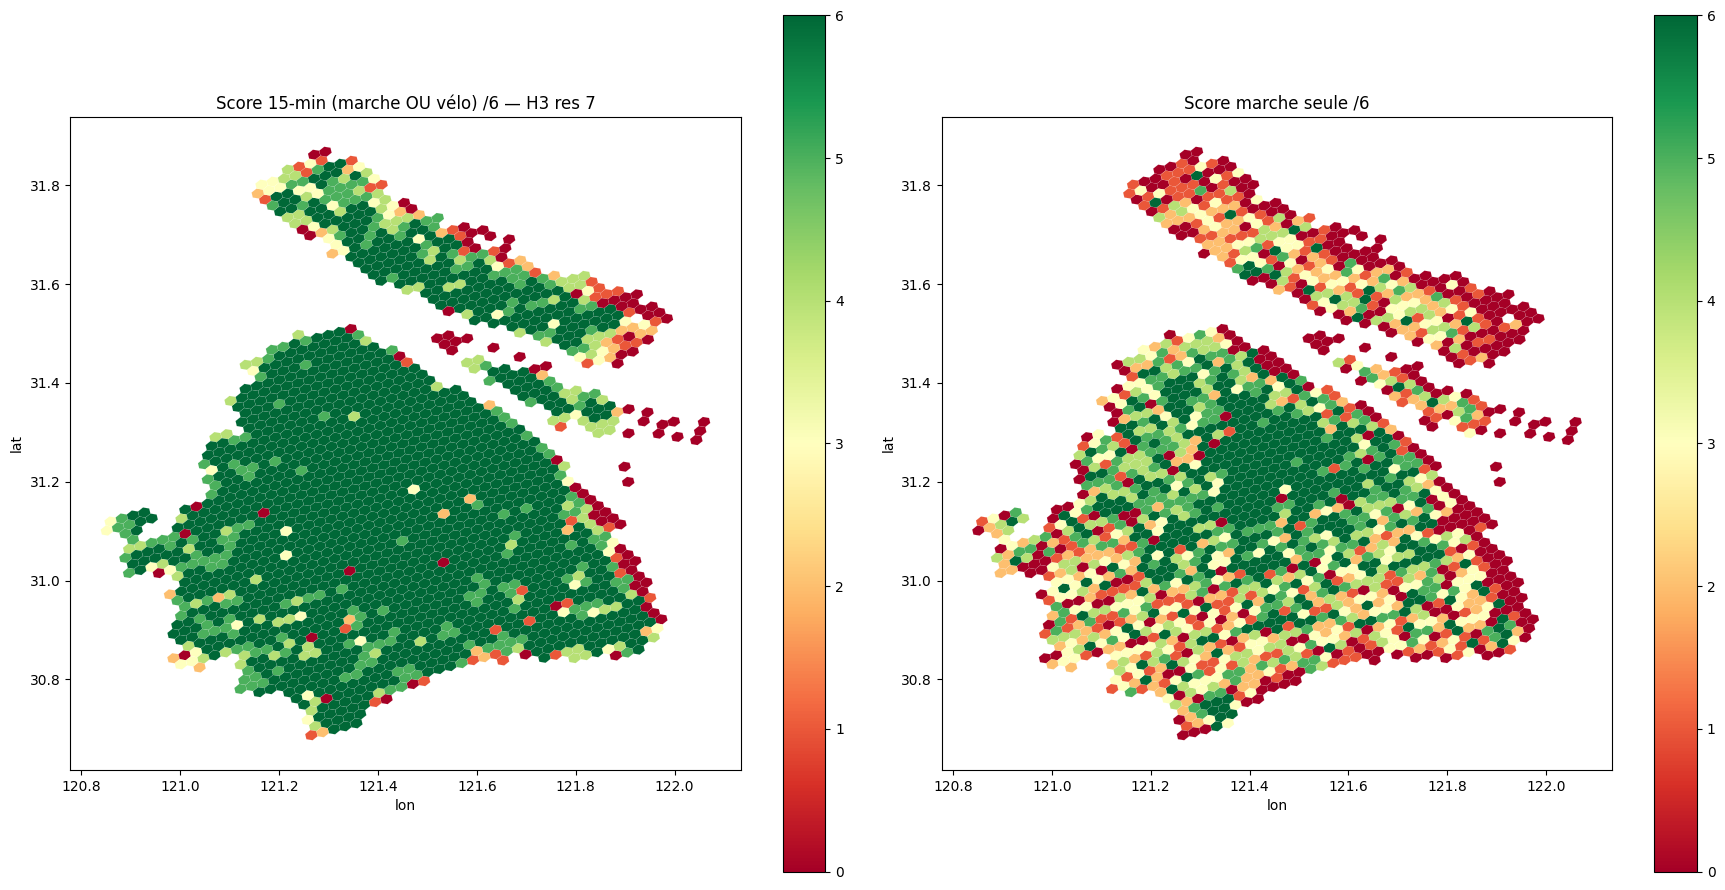

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
hexes.plot(column="baseline_score", cmap="RdYlGn", vmin=0, vmax=6, legend=True, linewidth=0.05,
           edgecolor="white", ax=axes[0])
axes[0].set_title(f"Score 15-min (marche OU vélo) /6 — H3 res {H3_RES}")
hexes.plot(column="n_walk", cmap="RdYlGn", vmin=0, vmax=6, legend=True, linewidth=0.05,
           edgecolor="white", ax=axes[1])
axes[1].set_title("Score marche seule /6")
for ax in axes: ax.set_aspect("equal"); ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.tight_layout(); plt.show()

## 8. Export

In [8]:
keep = (["cell", "clat", "clng", "snap_m", "baseline_score", "n_walk", "n_bike", "access_index"]
        + [f"acc_{k}" for k in CRIT] + [f"walk_{k}" for k in CRIT] + [f"bike_{k}" for k in CRIT])
out = hexes[keep + ["geometry"]].copy()
out.to_file(OUTPUTS / "hexes.geojson", driver="GeoJSON")
out.to_parquet(DATA_CLEAN / "hexes.parquet")
for f in [OUTPUTS / "hexes.geojson", DATA_CLEAN / "hexes.parquet"]:
    print(f"  {f.name:18} {f.stat().st_size/1e6:6.2f} MB | {len(out):,} hexagones")

  hexes.geojson        1.86 MB | 1,869 hexagones
  hexes.parquet        0.27 MB | 1,869 hexagones
